# Credit Scoring — Business Problem

## Problem Statement

Predict `SeriousDlqin2yrs` - whether a borrower will experience serious delinquency
(90+ days past due) within 2 years, based on financial behavior and demographic data.

## Business Value

Accurate default prediction helps financial institutions minimize credit losses,
make fair lending decisions, set appropriate credit limits, and comply with
regulatory requirements for risk management.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import BorderlineSMOTE

sns.set_theme(style='whitegrid', palette='muted')

In [ ]:
train = pd.read_csv("cs-training.csv")
test  = pd.read_csv("cs-test.csv")

In [8]:
train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [9]:
df = train.copy()

In [10]:
df.shape

(150000, 12)

In [11]:
df = df.drop("Unnamed: 0", axis=1)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [13]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [14]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [15]:
df.isnull().mean().round(4)

SeriousDlqin2yrs                        0.0000
RevolvingUtilizationOfUnsecuredLines    0.0000
age                                     0.0000
NumberOfTime30-59DaysPastDueNotWorse    0.0000
DebtRatio                               0.0000
MonthlyIncome                           0.1982
NumberOfOpenCreditLinesAndLoans         0.0000
NumberOfTimes90DaysLate                 0.0000
NumberRealEstateLoansOrLines            0.0000
NumberOfTime60-89DaysPastDueNotWorse    0.0000
NumberOfDependents                      0.0262
dtype: float64

Analys of duplicates

In [97]:
features = train.columns.values[0:30]
unique_max_train = []
unique_max_test = []
for feature in features:
    values = train[feature].value_counts()
    unique_max_train.append([feature, values.max(), values.idxmax()])

np.transpose((pd.DataFrame(unique_max_train, columns=['Feature', 'Max duplicates', 'Value'])).\
            sort_values(by = 'Max duplicates', ascending=False).head(15))

,10,8,1,4,11,9,7,2,5,3,6,0
Feature,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,SeriousDlqin2yrs,NumberOfTime30-59DaysPastDueNotWorse,NumberOfDependents,NumberRealEstateLoansOrLines,NumberOfOpenCreditLinesAndLoans,RevolvingUtilizationOfUnsecuredLines,DebtRatio,age,MonthlyIncome,Unnamed: 0
Max duplicates,142396,141662,139974,126018,86902,56188,13614,10878,4113,3837,2757,1
Value,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,49.0,5000.0,149984.0


EDA

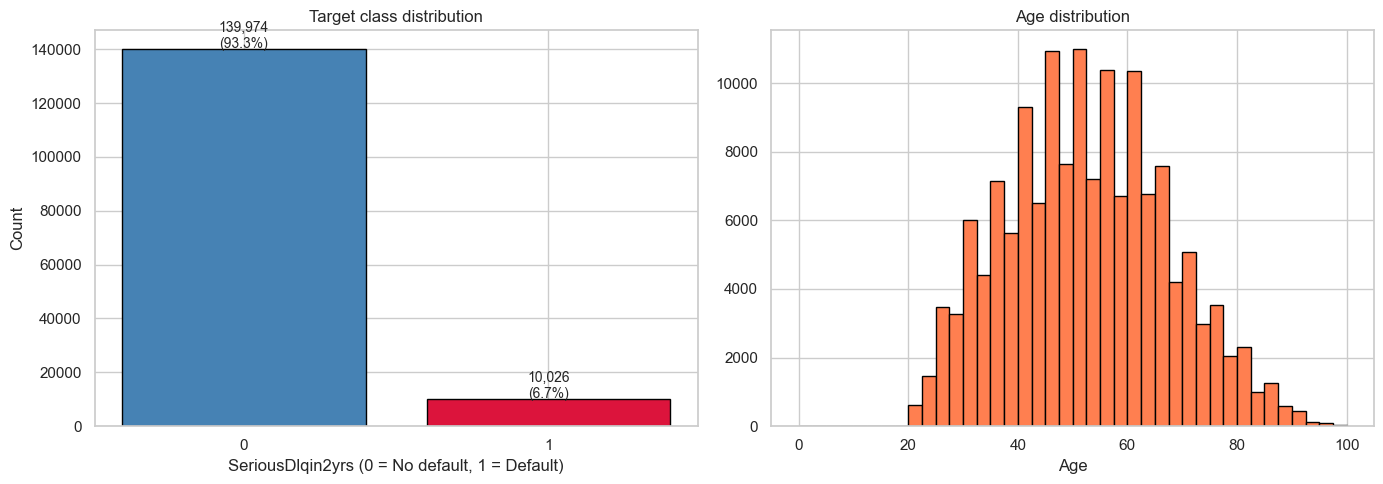

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['SeriousDlqin2yrs'].value_counts()
axes[0].bar(counts.index.astype(str), counts.values, color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Target class distribution')
axes[0].set_xlabel('SeriousDlqin2yrs (0 = No default, 1 = Default)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

df['age'].clip(upper=100).hist(bins=40, ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Age distribution')
axes[1].set_xlabel('Age')
plt.tight_layout()
plt.show()

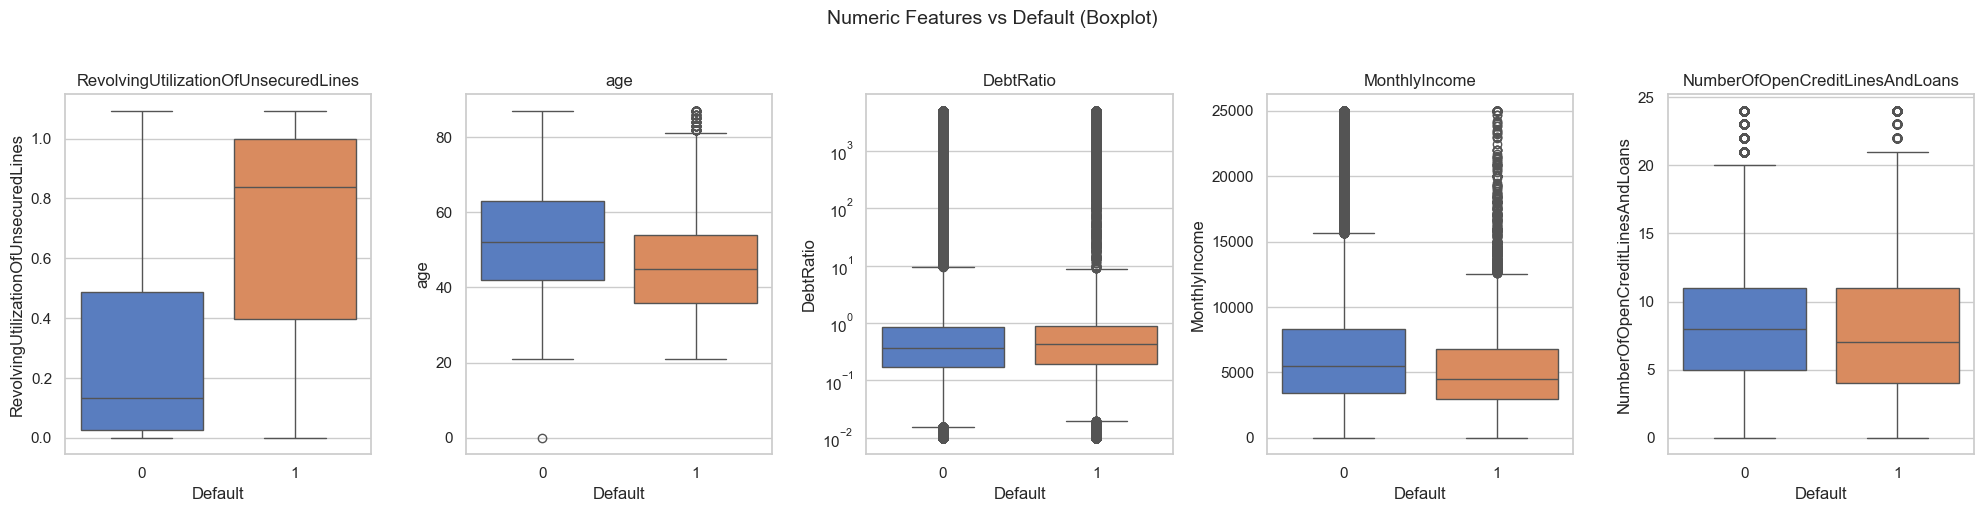

In [17]:
num_features = ['RevolvingUtilizationOfUnsecuredLines', 'age',
                'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']

fig, axes = plt.subplots(1, len(num_features), figsize=(20, 5))

for ax, feat in zip(axes, num_features):
    plot_df = df[[feat, 'SeriousDlqin2yrs']].dropna()
    plot_df[feat] = plot_df[feat].clip(upper=plot_df[feat].quantile(0.99))

    if feat == 'DebtRatio':
        plot_df[feat] = plot_df[feat].clip(lower=0.01)
        ax.set_yscale('log')

    sns.boxplot(data=plot_df, x='SeriousDlqin2yrs', y=feat, ax=ax, palette='muted')
    ax.set_title(feat)
    ax.set_xlabel('Default')

plt.suptitle('Numeric Features vs Default (Boxplot)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

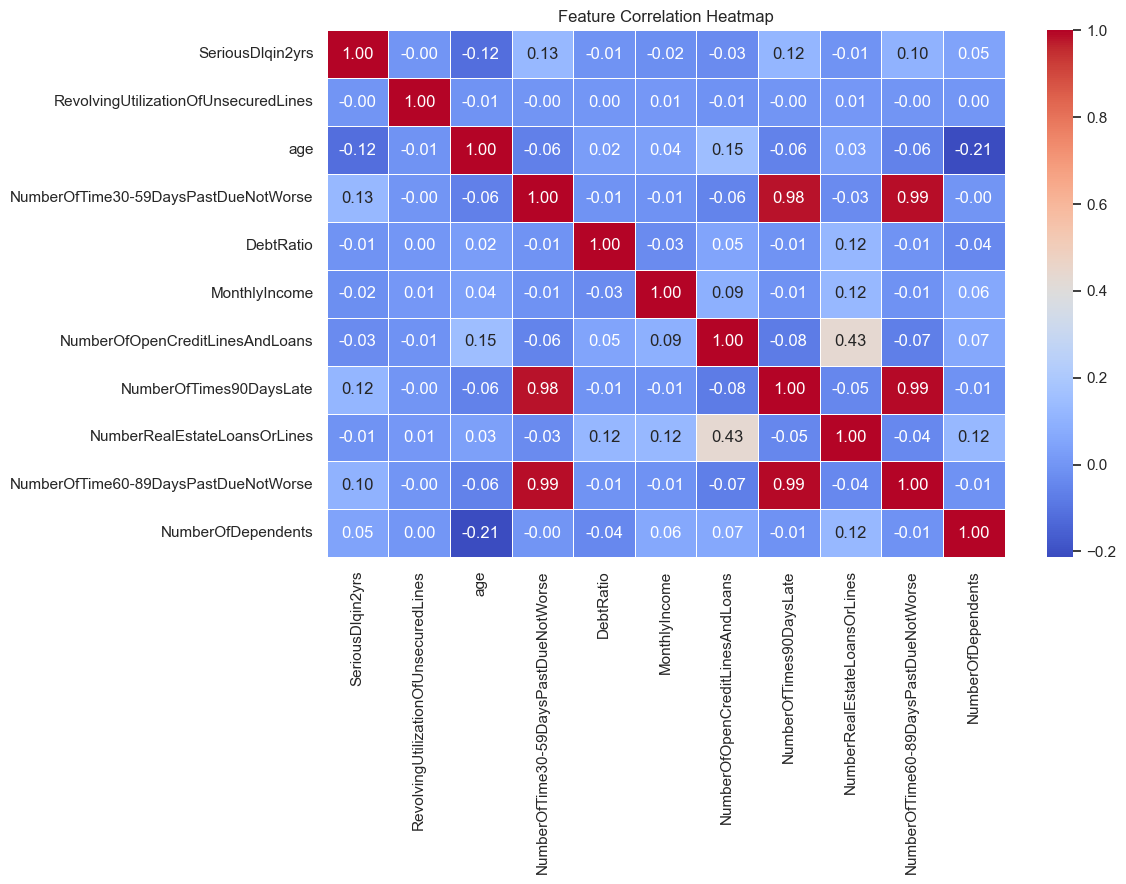

In [18]:
df_corr = df.copy()
corr = df_corr.corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Baseline Model + сделать беселайн для каждой новой фичи из FE, чтобы проследить что +, а что -

In [19]:
df_bl = train.copy()
df_bl = df_bl.drop('Unnamed: 0', axis=1)
df_bl = df_bl.fillna(df_bl.median(numeric_only=True))
df_bl = df_bl.drop_duplicates()

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=14),
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1),
    'RandomForest': RandomForestClassifier()
}

In [22]:
x_bl = df_bl.drop('SeriousDlqin2yrs', axis=1)
y_bl = df_bl['SeriousDlqin2yrs']
x_train_bl, x_test_bl, y_train_bl, y_test_bl = train_test_split(
    x_bl, y_bl, test_size=0.2, random_state=14, stratify=y_bl)

In [23]:
result = {}
models_step1 = {}

In [24]:
from sklearn.metrics import recall_score, precision_score

In [25]:
# recall, precision
for name, model in models.items():
    model.fit(x_train_bl, y_train_bl)
    proba_test  = model.predict_proba(x_test_bl)[:, 1]
    prediction_train= model.predict_proba(x_train_bl)[:, 1]
    prediction_test   = model.predict(x_test_bl)

    auc = roc_auc_score(y_test_bl, prediction_test)
    f1 = f1_score(y_test_bl, prediction_test)
    precision = precision_score(y_test_bl, prediction_test)
    recall = recall_score(y_test_bl, prediction_test)
    overfit = roc_auc_score(y_train_bl, prediction_train) - auc

    result[name] = {'ROC-AUC': round(auc,4), 'F1': round(f1,4),
                    "Precision": round(precision,4),
                    "Recall": round(recall,4), 'Overfit': round(overfit,4)}
    models_step1[name] = model
    print(result[name] )

{'ROC-AUC': np.float64(0.5203), 'F1': 0.0799, 'Precision': 0.5695, 'Recall': 0.043, 'Overfit': np.float64(0.1754)}
{'ROC-AUC': np.float64(0.6036), 'F1': 0.313, 'Precision': 0.5371, 'Recall': 0.2209, 'Overfit': np.float64(0.3103)}
{'ROC-AUC': np.float64(0.5945), 'F1': 0.2969, 'Precision': 0.5808, 'Recall': 0.1994, 'Overfit': np.float64(0.3018)}
{'ROC-AUC': np.float64(0.5855), 'F1': 0.2705, 'Precision': 0.5154, 'Recall': 0.1834, 'Overfit': np.float64(0.4145)}


In [26]:
results_step1 = pd.DataFrame(result).T.sort_values('ROC-AUC', ascending=False)
results_step1

,ROC-AUC,F1,Precision,Recall,Overfit
XGBoost,0.6036,0.3130,0.5371,0.2209,0.3103
LightGBM,0.5945,0.2969,0.5808,0.1994,0.3018
RandomForest,0.5855,0.2705,0.5154,0.1834,0.4145
LogisticRegression,0.5203,0.0799,0.5695,0.0430,0.1754


In [27]:
from sklearn.model_selection import cross_validate

In [28]:
for name, model in models.items():
    scores = cross_validate(model, x_bl, y_bl, cv=5,
                            scoring=['roc_auc', 'f1', 'precision', 'recall'])

    result[name] = {
        'ROC-AUC': round(np.mean(scores['test_roc_auc']), 4),
        'F1':  round(np.mean(scores['test_f1']), 4),
        'Precision': round(np.mean(scores['test_precision']), 4),
        'Recall': round(np.mean(scores['test_recall']), 4),
    }
    print(name, result[name])

results_cv = pd.DataFrame(result).T.sort_values('ROC-AUC', ascending=False)
results_cv

LogisticRegression {'ROC-AUC': np.float64(0.6969), 'F1': np.float64(0.0921), 'Precision': np.float64(0.6018), 'Recall': np.float64(0.0499)}
XGBoost {'ROC-AUC': np.float64(0.8556), 'F1': np.float64(0.2996), 'Precision': np.float64(0.5447), 'Recall': np.float64(0.2066)}
LightGBM {'ROC-AUC': np.float64(0.8644), 'F1': np.float64(0.287), 'Precision': np.float64(0.5878), 'Recall': np.float64(0.1899)}
RandomForest {'ROC-AUC': np.float64(0.8395), 'F1': np.float64(0.2804), 'Precision': np.float64(0.547), 'Recall': np.float64(0.1885)}


,ROC-AUC,F1,Precision,Recall
LightGBM,0.8644,0.2870,0.5878,0.1899
XGBoost,0.8556,0.2996,0.5447,0.2066
RandomForest,0.8395,0.2804,0.5470,0.1885
LogisticRegression,0.6969,0.0921,0.6018,0.0499


In [29]:
df_train = train.copy()
df_train = df_train.drop('Unnamed: 0', axis=1)
df_train = df_train.fillna(df_train.median(numeric_only=True))

X_raw = df_train.drop('SeriousDlqin2yrs', axis=1)
y_raw = df_train['SeriousDlqin2yrs']

df_t = test.copy()
df_t = df_t.drop('Unnamed: 0', axis=1)
df_t = df_t.fillna(df_t.median(numeric_only=True))

if 'SeriousDlqin2yrs' in df_t.columns:
    df_t = df_t.drop('SeriousDlqin2yrs', axis=1)

ll = LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
ll.fit(X_raw, y_raw)  # ← вот чего не хватало

y_final_proba = ll.predict_proba(df_t)[:, 1]

submission = pd.DataFrame({
    'Id': range(1, len(y_final_proba) + 1),
    'Probability': y_final_proba
})
submission.to_csv('submission_raw.csv', index=False)
print(submission.head(10).to_string(index=False))

 Id  Probability
  1     0.069046
  2     0.049671
  3     0.010812
  4     0.070775
  5     0.120282
  6     0.028706
  7     0.027808
  8     0.035310
  9     0.003390
 10     0.409487


На основе результатов сокращаю количество используемых моделей до 2 на основе f1_score: XGBoost, LightGBM. Также на основе результатов выбран: train_test_split

+feature engenireeng

In [ ]:
from sklearn.impute import SimpleImputer

In [104]:
df_fe = train.copy()
df_fe = df_fe.drop('Unnamed: 0', axis=1)
df_fe = df_fe.fillna(df_fe.median(numeric_only=True))
df_fe = df_fe.drop_duplicates()

In [105]:
df_fe['dependents_per_credit'] = (
    df_fe['NumberOfDependents'] /
    (df_fe['NumberOfOpenCreditLinesAndLoans'] + 1)
)

In [106]:
'''df_fe['debt_to_income'] = (
    df_fe['DebtRatio'] * df_fe['MonthlyIncome']
).clip(upper=df_fe['MonthlyIncome'].quantile(0.99) * 10)'''

"df_fe['debt_to_income'] = (\n    df_fe['DebtRatio'] * df_fe['MonthlyIncome']\n).clip(upper=df_fe['MonthlyIncome'].quantile(0.99) * 10)"

In [108]:
df_fe.shape

(149233, 12)

In [109]:
models_fe = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [ ]:
x_fe = df_fe.drop('SeriousDlqin2yrs', axis=1)
y_fe = df_fe['SeriousDlqin2yrs']
x_train_fe, x_test_fe, y_train_fe, y_test_fe = train_test_split(
    x_fe, y_fe, test_size=0.2, random_state=14, stratify=y_fe)

In [ ]:
result_1 = {}

In [ ]:
for name, model in models_fe.items():
    scores = cross_validate(model, x_fe, y_fe, cv=5,
                            scoring=['roc_auc', 'f1', 'precision', 'recall'])

    result_1[name] = {
        'ROC-AUC': round(np.mean(scores['test_roc_auc']), 4),
        'F1':  round(np.mean(scores['test_f1']), 4),
        'Precision': round(np.mean(scores['test_precision']), 4),
        'Recall': round(np.mean(scores['test_recall']), 4),
    }
    print(name, result_1[name])

results_cv = pd.DataFrame(result_1).T.sort_values('ROC-AUC', ascending=False)
results_cv

In [ ]:
result_2 = {}

In [ ]:
for name, model in models_fe.items():
    scores = cross_validate(model, x_fe, y_fe, cv=5,
                            scoring=['roc_auc', 'f1', 'precision', 'recall'])

    result_2[name] = {
        'ROC-AUC': round(np.mean(scores['test_roc_auc']), 4),
        'F1':  round(np.mean(scores['test_f1']), 4),
        'Precision': round(np.mean(scores['test_precision']), 4),
        'Recall': round(np.mean(scores['test_recall']), 4),
    }
    print(name, result_2[name])

results_cv = pd.DataFrame(result_2).T.sort_values('ROC-AUC', ascending=False)
results_cv

По XGBoost видим что метрики ухудшают результат

+advanced imputer

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
df_ai = train.copy()
df_ai = df_ai.drop('Unnamed: 0', axis=1)
df_ai = df_ai.drop_duplicates()

In [ ]:
models_ai = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [ ]:
x_ai = df_ai.drop('SeriousDlqin2yrs', axis=1)
y_ai = df_ai['SeriousDlqin2yrs']

In [ ]:
imputer = SimpleImputer(strategy='median')
x_train_ai = imputer.fit_transform(x_train_ai)
x_test_ai = imputer.transform(x_test_ai)

In [ ]:
result_ai = {}

In [ ]:
for name, model in models_ai.items():
    scores = cross_validate(model, x_ai, y_ai, cv=5,
                            scoring=['roc_auc', 'f1', 'precision', 'recall'])

    result_ai[name] = {
        'ROC-AUC': round(np.mean(scores['test_roc_auc']), 4),
        'F1':  round(np.mean(scores['test_f1']), 4),
        'Precision': round(np.mean(scores['test_precision']), 4),
        'Recall': round(np.mean(scores['test_recall']), 4),
    }
    print(name, result_ai[name])

results_cv = pd.DataFrame(result_ai).T.sort_values('ROC-AUC', ascending=False)
results_cv

По XGBoost стало хуже -> не исспользуем

+Outlier Removal

In [ ]:
df_cl = train.copy()
df_cl = df_cl.drop('Unnamed: 0', axis=1)
df_cl = df_cl.drop_duplicates()

In [ ]:
cols_to_check = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
                 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
                 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse',
                 'NumberOfTime60-89DaysPastDueNotWorse']

before = len(df_cl)
for col in cols_to_check:
    Q1  = df_cl[col].quantile(0.25)
    Q3  = df_cl[col].quantile(0.75)
    IQR = Q3 - Q1
    df_cl = df_cl[~((df_cl[col] < Q1 - 1.5*IQR) | (df_cl[col] > Q3 + 1.5*IQR))]

print(f'Removed: {before - len(df_cl)} rows')

In [ ]:
df_cl.shape

In [ ]:
x_cl = df_cl.drop('SeriousDlqin2yrs', axis=1)
y_cl = df_cl['SeriousDlqin2yrs']

In [ ]:
result = {}
models_step4 = {}

In [ ]:
models_cl = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [ ]:
result_cl = {}

In [ ]:
for name, model in models_cl.items():
    scores = cross_validate(model, x_cl, y_cl, cv=5,
                            scoring=['roc_auc', 'f1', 'precision', 'recall'])

    result_cl[name] = {
        'ROC-AUC': round(np.mean(scores['test_roc_auc']), 4),
        'F1':  round(np.mean(scores['test_f1']), 4),
        'Precision': round(np.mean(scores['test_precision']), 4),
        'Recall': round(np.mean(scores['test_recall']), 4),
    }
    print(name, result_cl[name])

results_cv = pd.DataFrame(result_cl).T.sort_values('ROC-AUC', ascending=False)
results_cv
# Сделать сабмишн с бест метрикой

Результат сильно упал, значит дальше не исспользуем

+Transformer
вместо Box-Cox-Transformer исспользую PowerTransformer, так как он может работать с 0

In [ ]:
df_tr = train.copy()
df_tr = df_tr.drop('Unnamed: 0', axis=1)
df_tr = df_tr.fillna(df_tr.median(numeric_only=True))
df_tr = df_tr.drop_duplicates()

In [ ]:
df_tr.shape

In [ ]:
x_tr = df_tr.drop('SeriousDlqin2yrs', axis=1)
y_tr = df_tr['SeriousDlqin2yrs']

In [ ]:
from sklearn.preprocessing import PowerTransformer

In [ ]:
pt = PowerTransformer(method='yeo-johnson')
x_tr = pt.fit_transform(x_tr)

In [ ]:
result_tr = {}

In [ ]:
models_tr = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [ ]:
for name, model in models_tr.items():
    scores = cross_validate(model, x_tr, y_tr, cv=5,
                            scoring=['roc_auc', 'f1', 'precision', 'recall'])

    result_tr[name] = {
        'ROC-AUC': round(np.mean(scores['test_roc_auc']), 4),
        'F1':  round(np.mean(scores['test_f1']), 4),
        'Precision': round(np.mean(scores['test_precision']), 4),
        'Recall': round(np.mean(scores['test_recall']), 4),
    }
    print(name, result_tr[name])

results_cv = pd.DataFrame(result_tr).T.sort_values('ROC-AUC', ascending=False)
results_cv

слегка улучшил -> у XGBoost на 0.0001-> оставляем

+Lasso Feature Selection

In [ ]:
! pip install kydavra

In [ ]:
from kydavra import LassoSelector

In [ ]:
df_lr = df_tr.copy()

In [ ]:
df_tr.isnull().sum()

In [ ]:
all_features = list(df_lr.drop('SeriousDlqin2yrs', axis=1).columns)

In [ ]:
lasso_sel = LassoSelector()
selected_columns = lasso_sel.select(df_tr, 'SeriousDlqin2yrs')
removed_features = [f for f in all_features if f not in selected_columns]

In [ ]:
print(f'Selected ({len(selected_columns)}): {selected_columns}')
print(f'Removed  ({len(removed_features)}): {removed_features}')

In [ ]:
x_lr = df_lr.drop('SeriousDlqin2yrs', axis=1)
y_lr = df_lr['SeriousDlqin2yrs']

In [ ]:
models_lr = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [ ]:
result_lr = {}

In [ ]:
for name, model in models_lr.items():
    scores = cross_validate(model, x_lr, y_lr, cv=5,
                            scoring=['roc_auc', 'f1', 'precision', 'recall'])

    result_lr[name] = {
        'ROC-AUC': round(np.mean(scores['test_roc_auc']), 4),
        'F1':  round(np.mean(scores['test_f1']), 4),
        'Precision': round(np.mean(scores['test_precision']), 4),
        'Recall': round(np.mean(scores['test_recall']), 4),
    }
    print(name, result_lr[name])

results_cv = pd.DataFrame(result_lr).T.sort_values('ROC-AUC', ascending=False)
results_cv

Хуже, хуже убираем

+Standardization

In [ ]:
df_st = df_tr.copy()

In [ ]:
x_st = df_st.drop('SeriousDlqin2yrs', axis=1)
y_st = df_st['SeriousDlqin2yrs']

In [ ]:
st = StandardScaler()
x_st = st.fit_transform(x_st)

In [ ]:
models_st = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [ ]:
result_st = {}

In [ ]:
for name, model in models_st.items():
    scores = cross_validate(model, x_st, y_st, cv=5,
                            scoring=['roc_auc', 'f1', 'precision', 'recall'])

    result_st[name] = {
        'ROC-AUC': round(np.mean(scores['test_roc_auc']), 4),
        'F1':  round(np.mean(scores['test_f1']), 4),
        'Precision': round(np.mean(scores['test_precision']), 4),
        'Recall': round(np.mean(scores['test_recall']), 4),
    }
    print(name, result_st[name])

results_cv = pd.DataFrame(result_st).T.sort_values('ROC-AUC', ascending=False)
results_cv

+BorderlineSMOTE

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import BorderlineSMOTE

In [ ]:
result_smote = {}

In [ ]:
models_smote = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [ ]:
for name, model in models_smote.items():
    pipe = Pipeline([
        ('smote', BorderlineSMOTE(random_state=14, kind='borderline-1')),
        ('model', model)
    ])
    scores = cross_validate(pipe, x_st, y_st, cv=5,
                            scoring=['roc_auc', 'f1', 'precision', 'recall'])

    result_smote[name] = {
        'ROC-AUC':   round(np.mean(scores['test_roc_auc']), 4),
        'F1':        round(np.mean(scores['test_f1']), 4),
        'Precision': round(np.mean(scores['test_precision']), 4),
        'Recall':    round(np.mean(scores['test_recall']), 4),
    }
    print(name, result_smote[name])

results_cv = pd.DataFrame(result_smote).T.sort_values('ROC-AUC', ascending=False)
results_cv


+Threshold Tuning

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

In [ ]:
models_tt = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [ ]:
result_thresh = {}

In [ ]:
for name, model in models_tt.items():
    pipe = Pipeline([
        ('smote', BorderlineSMOTE(random_state=14, kind='borderline-1')),
        ('model', model)
    ])

    fold_thresholds = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=14)

    for train_idx, val_idx in cv.split(x_st, y_st):
        X_tr, X_val = x_st[train_idx], x_st[val_idx]
        y_tr, y_val = y_st.iloc[train_idx], y_st.iloc[val_idx]

        pipe_fold = clone(pipe)
        pipe_fold.fit(X_tr, y_tr)

        proba_val = pipe_fold.predict_proba(X_val)[:, 1]
        prec, rec, thresh = precision_recall_curve(y_val, proba_val)
        f1 = 2 * prec * rec / (prec + rec + 1e-9)
        fold_thresholds.append(thresh[np.argmax(f1[:-1])])

    best_thresh = np.mean(fold_thresholds)

    scores = cross_validate(pipe, x_st, y_st, cv=5,
                            scoring=['roc_auc', 'f1', 'precision', 'recall'])

    result_thresh[name] = {
        'ROC-AUC':   round(np.mean(scores['test_roc_auc']), 4),
        'F1':        round(np.mean(scores['test_f1']), 4),
        'Precision': round(np.mean(scores['test_precision']), 4),
        'Recall':    round(np.mean(scores['test_recall']), 4),
        'Threshold': round(best_thresh, 4),
    }
    print(name, result_smote[name])

results_cv = pd.DataFrame(result_thresh).T.sort_values('ROC-AUC', ascending=False)
results_cv

Ничего не происходит, поэтому не будем исспользовать

# Best model

In [ ]:
best_name  = results_smote_df['F1'].astype(float).idxmax()
best_model = models_smote[best_name]

pipe = Pipeline([
    ('smote', BorderlineSMOTE(random_state=14, kind='borderline-1')),
    ('model', best_model)
])

scores = cross_validate(pipe, x_st, y_st, cv=5,
                        scoring=['roc_auc', 'f1', 'precision', 'recall'])

print(f'Best model: {best_name}')

In [ ]:
pipe = Pipeline([
    ('smote', BorderlineSMOTE(random_state=14, kind='borderline-1')),
    ('model', best_model)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=14)
y_proba_oof = np.zeros(len(y_st))

for train_idx, val_idx in cv.split(x_st, y_st):
    X_tr, X_val = x_st[train_idx], x_st[val_idx]
    y_tr = y_st.iloc[train_idx]

    p = clone(pipe)
    p.fit(X_tr, y_tr)
    y_proba_oof[val_idx] = p.predict_proba(X_val)[:, 1]

y_pred_oof = (y_proba_oof >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_st, y_pred_oof, ax=axes[0],
    display_labels=['No Default', 'Default'], cmap='Blues'
)
axes[0].set_title(f'Confusion Matrix — {best_name} (OOF)')

prec, rec, _ = precision_recall_curve(y_st, y_proba_oof)
axes[1].plot(rec, prec, color='steelblue', lw=2)
axes[1].fill_between(rec, prec, alpha=0.2, color='steelblue')
axes[1].set_title(f'Precision-Recall Curve — {best_name} (OOF)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(classification_report(y_st, y_pred_oof, target_names=['No Default', 'Default']))

In [73]:
df = train.copy()
df = df.drop('Unnamed: 0', axis=1)
df = df.fillna(df.median(numeric_only=True))
df = df.drop_duplicates()

In [74]:
x = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

In [75]:
from sklearn.preprocessing import PowerTransformer

In [76]:
pt = PowerTransformer(method='yeo-johnson')
x = pt.fit_transform(x)

In [77]:
st = StandardScaler()
x = st.fit_transform(x)

In [78]:
smote = BorderlineSMOTE(random_state=14, kind='borderline-1')
x, y = smote.fit_resample(x, y)

In [79]:
xgb = XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss')

In [80]:
from sklearn.model_selection import cross_validate

In [81]:
scores = cross_validate(xgb, x, y, cv=5,
                        scoring=['roc_auc', 'f1', 'precision', 'recall'])

result_final = {
    'ROC-AUC':   [round(np.mean(scores['test_roc_auc']), 4)],
    'F1':        [round(np.mean(scores['test_f1']), 4)],
    'Precision': [round(np.mean(scores['test_precision']), 4)],
    'Recall':    [round(np.mean(scores['test_recall']), 4)],
}

xgb.fit(x, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)

In [82]:
results = pd.DataFrame(result_final).sort_values('ROC-AUC', ascending=False)
results

,ROC-AUC,F1,Precision,Recall
0,0.9846,0.9323,0.9608,0.9144


In [100]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def evalBinaryClassifier(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion Matrix
    cm_display = np.array([[f'True Negatives\n{tn}', f'False Positives\n{fp}'],
                            [f'False Negatives\n{fn}', f'True Positives\n{tp}']])
    colors = np.array([[0.2, 0.8], [0.8, 0.4]])
    axes[0].imshow(colors, cmap='Blues', vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm_display[i, j], ha='center', va='center',
                        fontsize=12, color='white' if colors[i,j] < 0.5 else 'black')
    axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(['0', '1']); axes[0].set_yticklabels(['0', '1'])
    axes[0].set_xlabel('Predicted Values'); axes[0].set_ylabel('True Values')
    axes[0].set_title('Confusion Matrix')

    # Distribution of Predictions
    axes[1].hist(y_proba[y == 0], bins=30, alpha=0.6, color='salmon',
                label='Negatives', density=True)
    axes[1].hist(y_proba[y == 1], bins=30, alpha=0.6, color='green',
                label='Positives', density=True)
    axes[1].axvline(0.5, color='blue', linestyle='--', label='Boundary')
    axes[1].set_xlabel('Positive Probability (predicted)')
    axes[1].set_ylabel('Samples (normalized scale)')
    axes[1].set_title('Distributions of Predictions')
    axes[1].legend()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y, y_proba)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color='green', label=f'ROC curve (area = {roc_auc:.2f})')
    axes[2].plot([0, 1], [0, 1], color='gray', linestyle='--')
    idx = np.argmin(np.abs(thresholds - 0.5))
    axes[2].scatter(fpr[idx], tpr[idx], color='blue', zorder=5, label='Decision Point')
    axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
    axes[2].set_title('ROC Curve')
    axes[2].legend()

    plt.suptitle('Score Analysis', fontsize=14)
    plt.tight_layout()
    plt.show()

    from sklearn.metrics import precision_score, recall_score, f1_score
    print(f"Precision: {precision_score(y, y_pred):.2f} | "
          f"Recall: {recall_score(y, y_pred):.2f} | "
          f"F1 Score: {f1_score(y, y_pred):.2f} |")

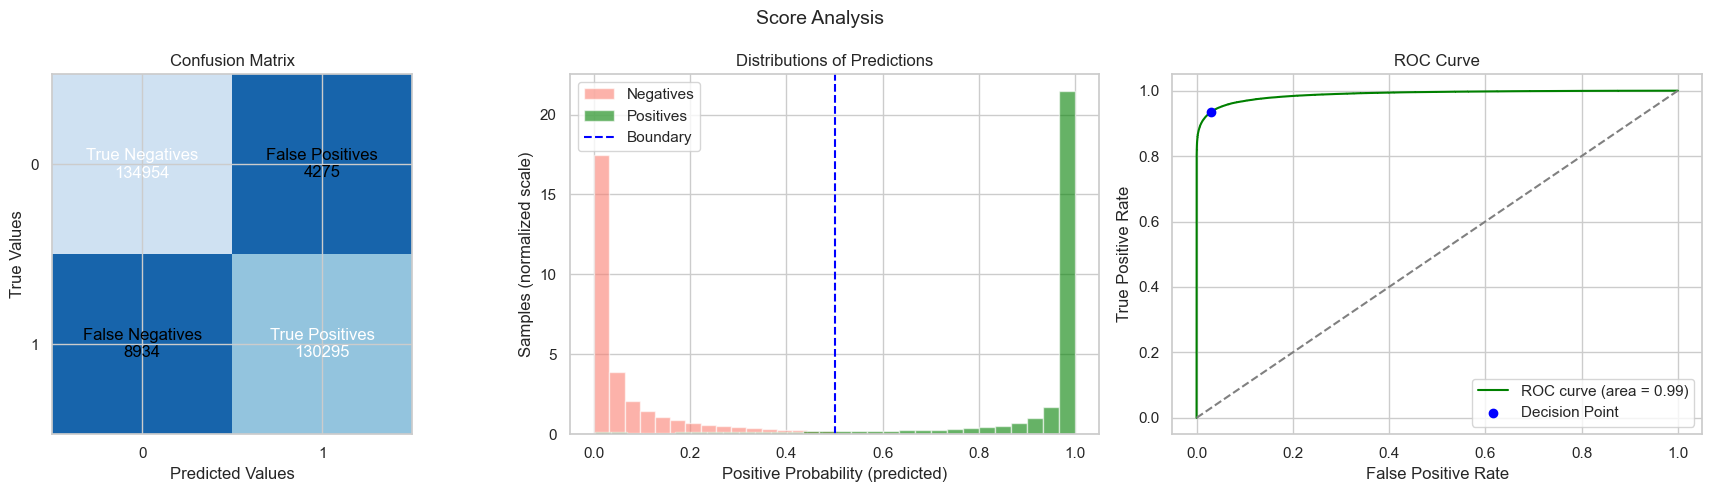

Precision: 0.97 | Recall: 0.94 | F1 Score: 0.95 |


In [101]:
evalBinaryClassifier(xgb, x, y)

Анализ оверфиттинга

In [83]:
y_train_pred = xgb.predict_proba(x)[:, 1]
train_auc = roc_auc_score(y, y_train_pred)
cv_auc = np.mean(scores['test_roc_auc'])

print(f"Overfitting:       {train_auc - cv_auc:.4f}")

Overfitting:       0.0042


Overfitting < 0.02 -> всё ок

Model interpretation

In [84]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [85]:
import shap

Без стандартизации чтоб сравнить

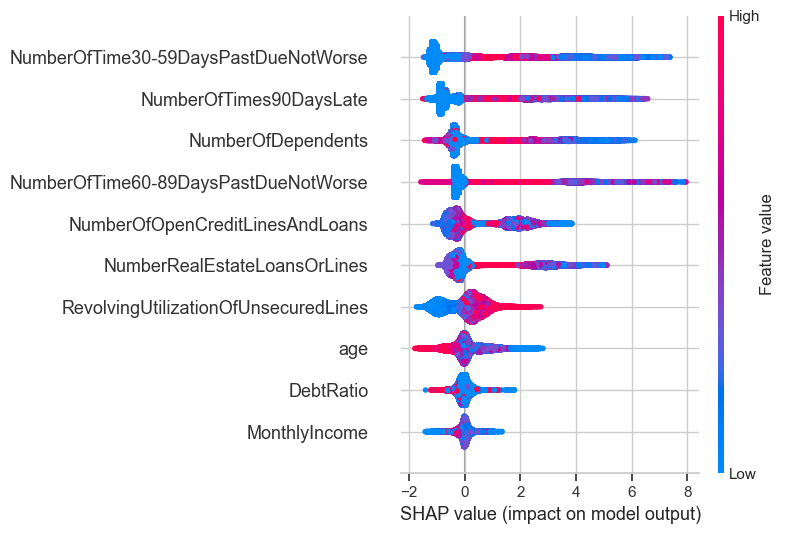

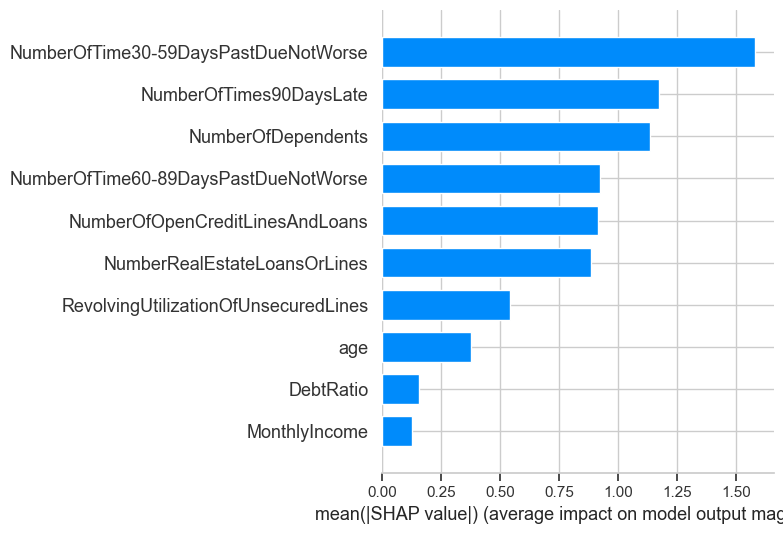

In [92]:
df_shap = df.drop('SeriousDlqin2yrs', axis=1)
feature_names = df_shap.columns.tolist()

smote_raw = BorderlineSMOTE(random_state=14)
x_raw, y_raw = smote_raw.fit_resample(df_shap.values, df['SeriousDlqin2yrs'])

xgb_shap = XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss')
xgb_shap.fit(x_raw, y_raw)

explainer = shap.TreeExplainer(xgb_shap)
shap_values = explainer.shap_values(x_raw)

shap.summary_plot(shap_values, x_raw, feature_names=feature_names)
shap.summary_plot(shap_values, x_raw, feature_names=feature_names, plot_type='bar')

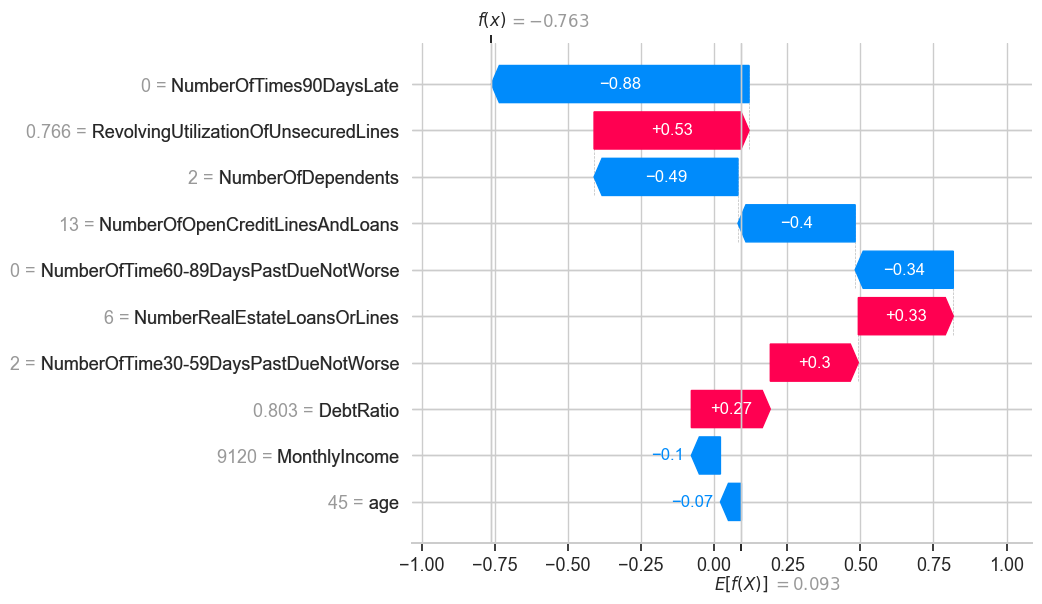

In [95]:
explainer_new = shap.Explainer(xgb_shap)
shap_values_new = explainer_new(pd.DataFrame(x_raw, columns=feature_names))

shap.plots.waterfall(shap_values_new[0]) 

+optuna tuning

In [53]:
! pip install optuna
import optuna

In [54]:
from optuna.samplers import TPESampler

In [55]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import cross_val_score

In [56]:
def objective_xgb_cv(trial, X_train_cv, y_train_cv):
    param = {
        "n_jobs": -1,
        "random_state": 42,
        "eval_metric": "logloss",
        "verbosity": 0,
        "n_estimators": trial.suggest_int("n_estimators", 50, 1000, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0, step=0.05),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0, step=0.05),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0, step=0.1),
    }

    model = XGBClassifier(**param)

    scores = cross_val_score(
        estimator=model,
        X=X_train_cv,
        y=y_train_cv,
        scoring="average_precision",
        cv=5,
        n_jobs=-1,
    )

    return np.mean(scores)


study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study.optimize(
    lambda trial: objective_xgb_cv(trial, X_train_cv=x, y_train_cv=y),
    n_trials=20,
    show_progress_bar=True,
)

print(f"Finished trials: {len(study.trials)}")
print(f"Best Average Precision: {study.best_trial.value:.4f}")
print("\nBest params:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

  0%|          | 0/20 [00:00<?, ?it/s]

Finished trials: 20
Best Average Precision: 0.9892

Best params:
  n_estimators: 350
  learning_rate: 0.05082810678983569
  max_depth: 11
  min_child_weight: 9
  subsample: 0.8
  colsample_bytree: 0.75
  reg_alpha: 0.026174223853672064
  reg_lambda: 1.4565123061191486e-05
  gamma: 0.0


In [58]:
best_params = study.best_trial.params.copy()

xgb = XGBClassifier(**best_params, random_state=42, n_jobs=-1, eval_metric="logloss", verbosity=0)

scores = cross_validate(xgb, x, y, cv=5,
                        scoring=['roc_auc', 'f1', 'precision', 'recall'])

result_final = {
    'ROC-AUC':   [round(np.mean(scores['test_roc_auc']), 4)],
    'F1':        [round(np.mean(scores['test_f1']), 4)],
    'Precision': [round(np.mean(scores['test_precision']), 4)],
    'Recall':    [round(np.mean(scores['test_recall']), 4)],
}

pd.DataFrame(result_final, index=['XGB_Optuna'])
xgb.fit(x, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.75, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05082810678983569,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=11, max_leaves=None,
              min_child_weight=9, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=350, n_jobs=-1,
              num_parallel_tree=None, ...)

С оптуна стало хуже -> не исспользуем

Тест сет

In [62]:
df_test = test.copy()
df_test = df_test.drop('Unnamed: 0', axis=1)
df_test = df_test.fillna(df_test.median(numeric_only=True))

In [63]:
if 'SeriousDlqin2yrs' in df_test.columns:
    df_test = df_test.drop('SeriousDlqin2yrs', axis=1)

In [64]:
st = StandardScaler()
df_test = st.fit_transform(df_test)

In [65]:
y_final = xgb.predict_proba(df_test)[:, 1]

In [66]:
submission = pd.DataFrame({
    'Id':         range(1, len(y_final) + 1),
    'Probability': y_final
})
submission.to_csv('submission_almost_final_2.csv', index=False)
submission.head()

,Id,Probability
0,1,0.290867
1,2,0.802075
2,3,0.986287
3,4,0.996328
4,5,0.526677


По методу среднее от предикшнс топ моделей

In [111]:
from sklearn.ensemble import VotingClassifier

In [136]:
xgb_e = XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss')
lgbm_e = LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)

ensemble = VotingClassifier(
    estimators=[('xgb', xgb_e), ('lgbm', lgbm_e)],
    voting='soft'
)

In [137]:
ensemble.fit(x, y)

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_co...s=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=-1,
                                            num_parallel_tree=None, ...)),
                             ('lgbm',
                              LGBMClassifier(n_jobs=-1, random_state=14,
                                             verbose=-1))],
                 voting='soft')

In [138]:
scores_ens = cross_validate(ensemble, x, y, cv=5,
                            scoring=['roc_auc', 'f1', 'precision', 'recall'])

pd.DataFrame({
    'ROC-AUC':   [round(np.mean(scores_ens['test_roc_auc']), 4)],
    'F1':        [round(np.mean(scores_ens['test_f1']), 4)],
    'Precision': [round(np.mean(scores_ens['test_precision']), 4)],
    'Recall':    [round(np.mean(scores_ens['test_recall']), 4)],
}, index=['Ensemble'])

,ROC-AUC,F1,Precision,Recall
Ensemble,0.9823,0.9263,0.9523,0.909


Final submission с таким методом

In [139]:
df_test = test.copy()
df_test = df_test.drop('Unnamed: 0', axis=1)
df_test = df_test.fillna(df_test.median(numeric_only=True))

In [140]:
if 'SeriousDlqin2yrs' in df_test.columns:
    df_test = df_test.drop('SeriousDlqin2yrs', axis=1)

In [141]:
x_test = st.transform(df_test)

In [142]:
y_final = ensemble.predict_proba(x_test)[:, 1]

In [143]:
submission = pd.DataFrame({
    'Id': range(1, len(y_final) + 1),
    'Probability': y_final
})
submission.to_csv('submission_ensemble.csv', index=False)
submission.head()

,Id,Probability
0,1,0.697818
1,2,0.782324
2,3,0.945904
3,4,0.987124
4,5,0.728050


## Ethical Considerations

### Data Privacy
- The dataset contains personal financial data — income, debt, and payment history
- Data must be anonymized before use; individuals must not be re-identifiable

### Model Fairness
- The model must not discriminate based on protected attributes (age, gender, race)
- `age` is included as a risk indicator; its impact must be regularly audited
- Predictions should be equally calibrated across demographic groups

### Imbalance & Sampling Ethics
- BorderlineSMOTE creates synthetic samples — these must not be treated as real data
- Oversampling only in train set; test set reflects the true population distribution

### Data Usage
- Data used for educational purposes only
- Production deployment must comply with:
  - GDPR (EU borrowers)
  - Fair Credit Reporting Act (FCRA) — US
  - Equal Credit Opportunity Act (ECOA) — US

### Security
- Credit risk scores must not be exposed to unauthorized third parties
- Model decisions affecting credit must be explainable and auditable